# DDPO for SD-3.5 — online RL with metric rewards (Flow-GRPO SDE sampler)

Diffusion-DPO with self-generated metric preferences left the model unchanged (β=100, margins ~1e-3).
This notebook trains the same LoRA adapter with **online RL**: sample K images per prompt with a
stochastic (SDE) sampler, score them with the axis reward, standardise within the prompt group
(advantage), and push the policy towards high-reward samples with PPO — DDPO's objective, made possible
on rectified flow by the Flow-GRPO SDE, whose Gaussian steps have a log-probability.

* rollouts at **768², T=10 SDE steps, guidance 4.5**, K=8 samples × 8 prompts per epoch;
* reward = the DPO reward (aesthetic: NIMA + LAION-aes; technical: MUSIQ + TOPIQ-NR), robust-z within the group;
* LR 1e-4 on LoRA rank 32 (DDPO / Flow-GRPO regime, ~40× the DPO LR); optional KL to the reference (`beta_kl`);
* the saved adapter loads exactly like a DPO one (`generate_triplets.py --dpo-lora …/lora_ddpo`), inference stays 28 ODE steps at 1024².

**Identity term (added after the first run drifted: maple neck, tremolo, cables).** The reward is now
`z_group(quality) + identity_lam · min(0, (CLIP-sim − τ)/σ)`: CLIP ViT-L/14 similarity to the 50 reference photos,
calibrated on the untuned model's own samples, penalised only below that level. Advantage stays group-relative
(`adv_mode: group`): a running baseline (`global`) was tried and collapsed — once the shape penalty kicks in every
advantage is negative and PPO drifts randomly (shape 1.0 → 0.3 in 4 epochs). Config: `identity:` block in
`configs/ddpo_*.yaml`, `identity_lam: 1.0` (0 = the first run's behaviour). Output run: `RUN` (default `lora_ddpo_id`).

**Shape term (the priority: the geometry must not change).** Every rollout is paired with a rollout of the
reference model from the *same* noise; the multi-scale Pearson correlation of their Sobel edge maps (`shape`,
1 = identical layout; colour/texture ≈ 1, hardware removed ≈ 0.92, 4 px shift ≈ 0.8, 10 % zoom ≈ 0.26) enters
the reward as `shape_lam · min(0, shape − (1 − shape_tol))` with `shape_lam 5`, `shape_tol 0.05`. Costs one extra
no-grad rollout per sample (≈ +40 % epoch time). `shape_lam: 0` switches it off.

What to watch: **`reward_mean` per epoch must go up**, **`identity` must stay near τ** and **`shape` must stay
above ~0.9** (it starts at 1.0) and the raw metrics with it. When it plateaus or the
images start looking over-processed (reward hacking), stop — that checkpoint is the survey manipulation.
Budget on A100: ≈ 8–12 min per epoch → 30 epochs ≈ 5 h per axis (resumable via `--init-lora --start-epoch`).

## 0. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
import os, shutil, json, glob

DRIVE    = '/content/drive/MyDrive/Doktorat/content'
RESULTS  = f'{DRIVE}/results'
LORA     = f'{RESULTS}/merged_finetune/rw'
DATASET  = '/content/drive/MyDrive/Doktorat/Dokumetacja/reward-GENERATED/Dataset/RufGen'
MANIFEST = f'{DATASET}/tables/guitar_manifest.csv'
CATALOG  = f'{DATASET}/combinations.json'
GEN3     = f'{DATASET}/generated_v3'
STEPS, GUIDANCE = 28, 4.5
RUN = 'lora_ddpo_id2'         # identity + shape terms, group advantage; lora_ddpo = no identity, lora_ddpo_id = failed global-baseline run
REFS = [f'{DATASET}/../gitarki/1024/whole', f'{DATASET}/../gitarki/1024/body']
REPO_SRC = '/content/drive/MyDrive/Doktorat/Dokumetacja/reward-GENERATED/code/sd35-dpo'
REPO = '/content/sd35-dpo'
shutil.rmtree(REPO, ignore_errors=True)
shutil.copytree(REPO_SRC, REPO, ignore=shutil.ignore_patterns('.git', '__pycache__', '.DS_Store'))
%cd {REPO}
for ax in ['aesthetic', 'technical']:
    !sed -i "s#^plain_lora:.*#plain_lora: {LORA}#; s#^manifest:.*#manifest: {MANIFEST}#" configs/ddpo_{ax}.yaml configs/{ax}.yaml
!grep -hE "^(plain_lora|manifest|out_dir|learning_rate|beta_kl|resolution|num_steps):" configs/ddpo_aesthetic.yaml
!nvidia-smi -L
!pip install -q -r requirements.txt
!pip uninstall -y -q torchao 2>/dev/null
from huggingface_hub import login
from google.colab import userdata
login(userdata.get('HF_TOKEN'))

Mounted at /content/drive
/content/sd35-dpo
plain_lora: /content/drive/MyDrive/Doktorat/content/results/merged_finetune/rw
manifest: /content/drive/MyDrive/Doktorat/Dokumetacja/reward-GENERATED/Dataset/RufGen/tables/guitar_manifest.csv
out_dir: /content/drive/MyDrive/Doktorat/content/results/rl_aes
num_steps: 10
resolution: 768
learning_rate: 1.0e-4    # DDPO / Flow-GRPO LoRA regime (vs 2.56e-6 in DPO)
beta_kl: 0.0             # 0.004 = Flow-GRPO KL to the reference (extra forward per step)
GPU 0: NVIDIA A100-SXM4-40GB (UUID: GPU-fa5a561b-cb03-c22c-c74c-795bfb7fa2cc)


## 1. CPU smoke test (SDE log-prob consistency, PPO raises a synthetic reward)

In [ ]:
!python tests/smoke_ddpo_tiny.py

SDE log-prob consistent over 4 steps; sigmas [1.0, 0.858, 0.602, 0.009, 0.0]
[dpo] LoRA saved: /tmp/sd35ddpo_n_2ufn5g
[ddpo] epoch 1: reward +0.000±0.029  loss=-0.0000 clip=0.00 |ratio-1|=7.4e-04 (0.0 min)
[ddpo] epoch 2: reward +0.015±0.028  loss=0.0001 clip=0.00 |ratio-1|=2.7e-04 (0.0 min)
[ddpo] epoch 3: reward +0.009±0.025  loss=-0.0001 clip=0.00 |ratio-1|=3.0e-04 (0.0 min)
...
[ddpo] epoch 29: reward +0.024±0.031  loss=-0.0000 clip=0.00 |ratio-1|=5.5e-04 (0.3 min)
[ddpo] epoch 30: reward +0.039±0.034  loss=0.0008 clip=0.09 |ratio-1|=2.9e-03 (0.3 min)
[dpo] init from /tmp/sd35ddpo_n_2ufn5g/pytorch_lora_weights.safetensors: 30 tensors
reward +0.008 -> +0.032 (slope +0.0008/epoch); adapter reloaded (30 tensors)
[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 99), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 99), 

## 1b. Review the plan before touching the GPU

Prints the effective configuration of both axes and the resource plan (samples, forward passes,
memory, time). Read it — nothing below runs a full experiment until `REVIEW_OK = True` in section 2b.

In [ ]:
import yaml, torch, pandas as pd
def plan(cfg_path):
    c = yaml.safe_load(open(cfg_path))
    T, K, P = c['num_steps'], c['k_per_prompt'], c['prompts_per_epoch']
    n_samples = K * P
    fw_rollout = n_samples * T * (2 if c['guidance'] != 1.0 else 1) * (2 if c.get('shape_lam', 0) > 0 else 1)   # CFG doubles; shape term = paired reference rollout
    fw_train = n_samples * T * c['inner_epochs'] * (2 if c['guidance'] != 1.0 else 1) * (2 if c['beta_kl'] > 0 else 1)
    return dict(axis=c['axis'], metrics=list(c['metrics']), lora=os.path.basename(c['plain_lora']), out=c['out_dir'],
                resolution=c['resolution'], T=T, K=K, prompts_per_epoch=P, samples_per_epoch=n_samples,
                epochs=c['epochs'], total_samples=n_samples * c['epochs'],
                fwd_rollout_per_epoch=fw_rollout, fwd_train_per_epoch=fw_train,
                lr=c['learning_rate'], clip=c['clip_range'], beta_kl=c['beta_kl'], adv_clip=c['adv_clip'],
                identity_lam=c.get('identity_lam', 0), shape_lam=c.get('shape_lam', 0), shape_tol=c.get('shape_tol'), adv_mode=c.get('adv_mode', 'group'),
                lora_rank=c['lora_rank'], grad_ckpt=c['gradient_checkpointing'], save_every=c['save_every_epochs'])
df = pd.DataFrame([plan('configs/ddpo_aesthetic.yaml'), plan('configs/ddpo_technical.yaml')]).set_index('axis').T
display(df)
free, total = torch.cuda.mem_get_info()
print(f'GPU: {torch.cuda.get_device_name(0)}  free {free/1e9:.1f} / {total/1e9:.1f} GB')
for name, path in [('rw LoRA', f'{LORA}/pytorch_lora_weights.safetensors'), ('manifest', MANIFEST), ('catalog', CATALOG),
                   ('generated_v2/plain', f'{GEN3}/plain/SD35'), ('pool prompts', f'{DATASET}/pool/prompts.txt')]:
    print(('OK      ' if os.path.exists(path) else 'MISSING ') + f'{name}: {path}')
print('\nChecklist before section 3:')
print(' [ ] out_dir points at content/results/rl_* (a NEW run name if lora_ddpo already exists)')
print(' [ ] resolution 768 / T=10 / K=8 / 8 prompts: ~64 samples per epoch — change only if the smoke timing says so')
print(' [ ] beta_kl: 0 = pure DDPO (faster), 0.004 = Flow-GRPO KL (safer against reward hacking, +50% train time)')
print(' [ ] Drive has space: 30 epochs x 2 axes x ~50 MB of checkpoints (epoch_NNN/) + logs')

axis,aesthetic,technical
metrics,"[nima, laion_aes]","[musiq, topiq_nr]"
lora,rw,rw
out,/content/drive/MyDrive/Doktorat/content/result...,/content/drive/MyDrive/Doktorat/content/result...
resolution,768,768
T,10,10
K,8,8
prompts_per_epoch,8,8
samples_per_epoch,64,64
epochs,30,30
total_samples,1920,1920


GPU: NVIDIA A100-SXM4-40GB  free 42.0 / 42.4 GB
OK      rw LoRA: /content/drive/MyDrive/Doktorat/content/results/merged_finetune/rw/pytorch_lora_weights.safetensors
OK      manifest: /content/drive/MyDrive/Doktorat/Dokumetacja/reward-GENERATED/Dataset/RufGen/tables/guitar_manifest.csv
OK      catalog: /content/drive/MyDrive/Doktorat/Dokumetacja/reward-GENERATED/Dataset/RufGen/combinations.json
MISSING generated_v2/plain: /content/drive/MyDrive/Doktorat/Dokumetacja/reward-GENERATED/Dataset/RufGen/generated_v3/plain/SD35
OK      pool prompts: /content/drive/MyDrive/Doktorat/Dokumetacja/reward-GENERATED/Dataset/RufGen/pool/prompts.txt

Checklist before section 3:
 [ ] out_dir points at content/results/rl_* (a NEW run name if lora_ddpo already exists)
 [ ] resolution 768 / T=10 / K=8 / 8 prompts: ~64 samples per epoch — change only if the smoke timing says so
 [ ] beta_kl: 0 = pure DDPO (faster), 0.004 = Flow-GRPO KL (safer against reward hacking, +50% train time)
 [ ] Drive has space: 30 

## 2. Tiny GPU run — 1 epoch, 1 prompt, K=4 (loads SD-3.5, rw LoRA, reward, rollout, PPO step, save)

In [ ]:
!python scripts/run_ddpo.py --config configs/ddpo_aesthetic.yaml --epochs 1 --prompts-per-epoch 1 --k 4 --run-name ddpo_smoke

[pool] 178 unique prompts from manifest /content/drive/MyDrive/Doktorat/Dokumetacja/reward-GENERATED/Dataset/RufGen/tables/guitar_manifest.csv
axis=aesthetic metrics=['nima', 'laion_aes'] prompts=178 -> /content/drive/MyDrive/Doktorat/content/results/rl_aes/ddpo_smoke
DDPO: T=10 guidance=4.5 noise=0.7 res=768 K=4 prompts/epoch=1 epochs=1 lr=0.0001 clip=0.001 beta_kl=0.0 identity_lam=1.0 shape_lam=5.0 shape_tol=0.05 adv_mode=global

model.safetensors: downloading bytes:  28% 61.8M/224M [00:01<00:01, 91.6MB/s, 3.59MB/s  ]
model.safetensors: reconstructing file:  13% 28.6M/224M [00:01<00:08, 23.2MB/s]
model.safetensors: downloading bytes:  36% 80.7M/224M [00:01<00:02, 60.0MB/s, 7.19MB/s  ]
model.safetensors: downloading bytes:  42% 94.7M/224M [00:01<00:02, 55.4MB/s, 8.31MB/s  ]
model.safetensors: reconstructing file:  40% 90.2M/224M [00:02<00:02, 51.1MB/s, 7.07MB/s  ]
model.safetensors: downloading bytes:  51% 115M/224M [00:02<00:02, 53.2MB/s, 9.88MB/s  ]
model.safetensors: downloading by

## 2b. Review the smoke run — GO / NO-GO for the full series

Reads `ddpo_smoke/train_log.json`, extrapolates the epoch time to the full configuration, checks the
reward statistics and that the smoke adapter loads and differs from the reference. Set `REVIEW_OK = True`
at the end only if every line says OK; section 3 refuses to run otherwise.

In [ ]:
import json, os, torch, yaml
from safetensors.torch import load_file
smoke = f'{RESULTS}/rl_aes/ddpo_smoke'
log = json.load(open(f'{smoke}/train_log.json'))
h, c = log['history'][-1], log['config']
full = yaml.safe_load(open('configs/ddpo_aesthetic.yaml'))
checks = []
def check(ok, msg): checks.append(ok); print(('OK   ' if ok else 'FAIL ') + msg)

# 1. timing: smoke = 1 prompt x K samples; full = prompts_per_epoch x K
t_smoke = h['elapsed_min']
per_sample = t_smoke / h['n_samples']
t_epoch = per_sample * full['k_per_prompt'] * full['prompts_per_epoch']
t_total = t_epoch * full['epochs']
check(t_epoch < 20, f"epoch ≈ {t_epoch:.1f} min ({per_sample*60:.0f} s / sample incl. PPO) -> {full['epochs']} epochs ≈ {t_total/60:.1f} h per axis")
if t_epoch >= 20: print('     -> lower resolution to 512 or prompts_per_epoch to 4 in configs/ddpo_*.yaml')

# 2. reward / PPO health on the smoke epoch
check(h['reward_std'] > 0.05, f"reward spread within the group: std={h['reward_std']:.3f} (advantage needs variance)")
clip = c['clip_range']
check(h['ratio_dev'] < 3 * clip, f"|ratio-1| = {h['ratio_dev']:.1e} vs clip_range {clip:.0e} (window must contain the typical drift)")
if h['ratio_dev'] >= 3 * clip: print(f"     -> set clip_range to ~{h['ratio_dev']:.0e} in configs/ddpo_*.yaml (or lower learning_rate)")
check(h['clip_frac'] <= 0.6, f"PPO clip fraction {h['clip_frac']:.2f} (smoke over-estimates it: 1 prompt, correlated items; <0.3 expected in full epochs)")
check(h['loss'] == h['loss'] and abs(h['loss']) < 10, f"loss finite: {h['loss']:.4f}")
raws = {k[4:]: v for k, v in h.items() if k.startswith('raw_')}
print('     raw metrics of the smoke samples:', {k: round(v, 3) for k, v in raws.items()})
if 'shape' in raws: check(raws['shape'] > 0.95, f"shape similarity after 1 epoch {raws['shape']:.3f} (starts at 1.0; paired reference rollout works)")
if 'identity' in raws: check(0.3 < raws['identity'] < 1.0, f"identity score {raws['identity']:.3f} (CLIP top-5 sim; compare with tau in identity_calib.json)")

# 3. adapter saved, non-zero, loadable
sd = load_file(f'{smoke}/pytorch_lora_weights.safetensors')
n_b = sum(1 for k in sd if 'lora_B' in k); nz = sum(float(v.abs().sum()) > 0 for k, v in sd.items() if 'lora_B' in k)
check(n_b > 0 and nz > 0, f"adapter saved: {len(sd)} tensors, {nz}/{n_b} lora_B non-zero (moved after 1 epoch)")

# 4. memory headroom
free, total = torch.cuda.mem_get_info()
check(free > 8e9, f"GPU free now {free/1e9:.1f} GB of {total/1e9:.1f} (the smoke process has exited)")

print('\nALL OK -> set REVIEW_OK = True' if all(checks) else '\nFIX THE FAILED LINES FIRST (config in configs/ddpo_*.yaml), rerun section 2, then this cell')
REVIEW_OK = False   # <- flip to True after reading the lines above

OK   epoch ≈ 8.7 min (8 s / sample incl. PPO) -> 30 epochs ≈ 4.4 h per axis
OK   reward spread within the group: std=1.567 (advantage needs variance)
OK   |ratio-1| = 1.2e-03 vs clip_range 1e-03 (window must contain the typical drift)
OK   PPO clip fraction 0.25 (smoke over-estimates it: 1 prompt, correlated items; <0.3 expected in full epochs)
OK   loss finite: 0.0003
     raw metrics of the smoke samples: {'nima': 4.319, 'laion_aes': 5.014, 'identity': 0.833, 'shape': 1.0}
OK   shape similarity after 1 epoch 1.000 (starts at 1.0; paired reference rollout works)
OK   identity score 0.833 (CLIP top-5 sim; compare with tau in identity_calib.json)
OK   adapter saved: 382 tensors, 190/191 lora_B non-zero (moved after 1 epoch)
OK   GPU free now 42.0 GB of 42.4 (the smoke process has exited)

ALL OK -> set REVIEW_OK = True


## 3. Full runs (one per axis, resumable) — writes `{axis}/{RUN}`, calibrates identity on 128 pool images first

Rerun with `--init-lora {RESULTS}/rl_aes/lora_ddpo --start-epoch N` after a reset (checkpoints every 5 epochs in `epoch_NNN/`).

In [ ]:
!python scripts/run_ddpo.py --config configs/ddpo_aesthetic.yaml --run-name {RUN}

[pool] 178 unique prompts from manifest /content/drive/MyDrive/Doktorat/Dokumetacja/reward-GENERATED/Dataset/RufGen/tables/guitar_manifest.csv
axis=aesthetic metrics=['nima', 'laion_aes'] prompts=178 -> /content/drive/MyDrive/Doktorat/content/results/rl_aes/lora_ddpo_id2
DDPO: T=10 guidance=4.5 noise=0.7 res=768 K=8 prompts/epoch=8 epochs=30 lr=0.0001 clip=0.001 beta_kl=0.0 identity_lam=1.0 shape_lam=5.0 shape_tol=0.05 adv_mode=group
Loading pretrained model NIMA from /root/.cache/torch/hub/pyiqa/NIMA_InceptionV2_ava-b0c77c00.pth
Loading pretrained model MLP from /root/.cache/torch/hub/pyiqa/sac%2Blogos%2Bava1-l14-linearMSE.pth
Loading weights: 100% 590/590 [00:00<00:00, 2708.12it/s]
[identity] 100 reference embeddings (openai/clip-vit-large-patch14, top-5)
[identity] calibrated on 128 images: tau=0.8735 sigma=0.0206
[identity] lam=1.0 adv_mode=group
/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be r

In [ ]:
!python scripts/run_ddpo.py --config configs/ddpo_technical.yaml --run-name {RUN}

[pool] 178 unique prompts from manifest /content/drive/MyDrive/Doktorat/Dokumetacja/reward-GENERATED/Dataset/RufGen/tables/guitar_manifest.csv
axis=technical metrics=['musiq', 'topiq_nr'] prompts=178 -> /content/drive/MyDrive/Doktorat/content/results/rl_tech/lora_ddpo_id
DDPO: T=10 guidance=4.5 noise=0.7 res=768 K=8 prompts/epoch=8 epochs=30 lr=0.0001 clip=0.001 beta_kl=0.0 identity_lam=1.0 shape_lam=5.0 shape_tol=0.05 adv_mode=global
Downloading: "https://huggingface.co/chaofengc/IQA-PyTorch-Weights/resolve/main/musiq_koniq_ckpt-e95806b9.pth" to /root/.cache/torch/hub/pyiqa/musiq_koniq_ckpt-e95806b9.pth

 66% 68.1M/104M [00:01<00:01, 31.8MB/s]Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/hub.py", line 768, in download_url_to_file
    buffer = u.read(READ_DATA_CHUNK)
  File "/usr/lib/python3.13/http/client.py", line 494, in read
    s = self.fp.read(amt)
  File "/usr/lib/python3.13/socket.py", line 723, in readinto
    return self._sock.recv_i

## 4. Reward curves

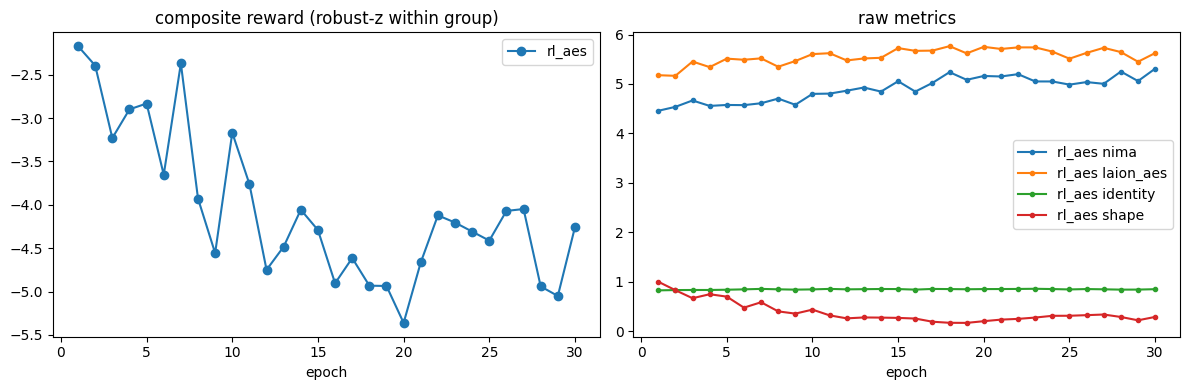

In [ ]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
for d in ['rl_aes', 'rl_tech']:
    p = f'{RESULTS}/{d}/{RUN}/train_log.json'
    if not os.path.exists(p): continue
    h = json.load(open(p))['history']
    axs[0].plot([x['epoch'] for x in h], [x['reward_mean'] for x in h], marker='o', label=d)
    for m in [k for k in h[0] if k.startswith('raw_')]:
        axs[1].plot([x['epoch'] for x in h], [x[m] for x in h], marker='.', label=f'{d} {m[4:]}')
axs[0].set_title('composite reward (robust-z within group)'); axs[0].legend(); axs[0].set_xlabel('epoch')
axs[1].set_title('raw metrics'); axs[1].legend(); axs[1].set_xlabel('epoch'); plt.tight_layout(); plt.show()

### Rollouts as a by-product dataset

With `save_rollouts: true` every training sample is kept: `lora_ddpo/rollouts/epoch_NNN/p{idx}_k{k}.png`
and `rollouts.csv` (reward, advantage, raw metrics, prompt). This is the "what the policy produced while
learning" dataset for the report — the drift of the metrics and of the look of the images over epochs.

rl_aes 1920 rollout images; {1: -2.171, 2: -2.395, 3: -3.23, 4: -2.9, 5: -2.832, 6: -3.653, 7: -2.37, 8: -3.928, 9: -4.557, 10: -3.169, 11: -3.76, 12: -4.75, 13: -4.482, 14: -4.057, 15: -4.291, 16: -4.904, 17: -4.614, 18: -4.932, 19: -4.935, 20: -5.361, 21: -4.664, 22: -4.121, 23: -4.205, 24: -4.309, 25: -4.413, 26: -4.07, 27: -4.049, 28: -4.94, 29: -5.051, 30: -4.257}


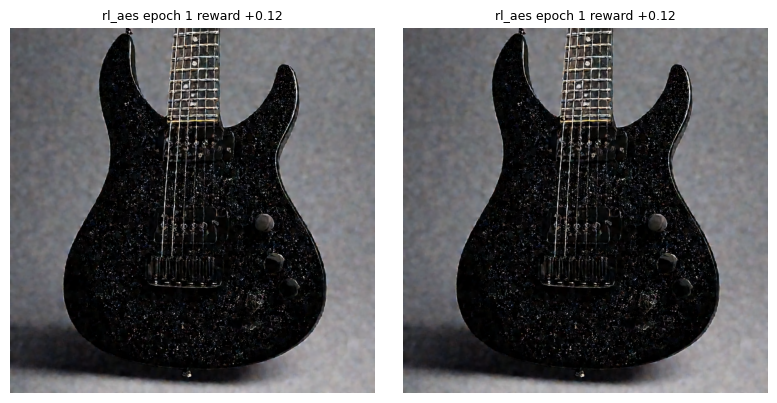

In [ ]:
import pandas as pd
from PIL import Image
for d in ['rl_aes', 'rl_tech']:
    p = f'{RESULTS}/{d}/{RUN}/rollouts/rollouts.csv'
    if not os.path.exists(p): continue
    ro = pd.read_csv(p)
    print(d, len(ro), 'rollout images;', ro.groupby('epoch').reward.mean().round(3).to_dict())
    # best rollout of the first and of the last epoch for the same prompt, side by side
    pi = ro.prompt_idx.iloc[0]
    sel = ro[ro.prompt_idx == pi]
    first, last = sel[sel.epoch == sel.epoch.min()], sel[sel.epoch == sel.epoch.max()]
    if len(first) and len(last):
        a, b = first.loc[first.reward.idxmax()], last.loc[last.reward.idxmax()]
        fig, axs = plt.subplots(1, 2, figsize=(8, 4))
        for ax, row in zip(axs, (a, b)):
            ax.imshow(Image.open(f'{RESULTS}/{d}/{RUN}/rollouts/{row.path}')); ax.axis('off')
            ax.set_title(f'{d} epoch {row.epoch} reward {row.reward:+.2f}', fontsize=9)
        plt.tight_layout(); plt.show()

## 5. Held-out reward gain vs the reference (same prompts/seeds, ODE sampler as in the survey)

In [ ]:
POOL = f'{DATASET}/pool'
for ax, d in [('aesthetic', 'rl_aes'), ('technical', 'rl_tech')]:
    lora = f'{RESULTS}/{d}/{RUN}'
    if os.path.exists(f'{lora}/pytorch_lora_weights.safetensors'):
        !python eval/reward_gain.py --config configs/{ax}.yaml --dpo-lora {lora} \
            --prompts {POOL}/prompts.txt --n-prompts 20 --seeds 100-102 --steps {STEPS} --guidance {GUIDANCE} \
            --out {RESULTS}/{d}/eval_lora_ddpo
        r = json.load(open(f'{RESULTS}/{d}/eval_lora_ddpo/report.json'))
        print(d, {m: (round(v['mean_gain'], 3), round(v['win_rate'], 2)) for m, v in r.items() if isinstance(v, dict) and 'win_rate' in v})

## 6. Quick look: reference vs DDPO adapters on 3 prompts (ODE sampler, 1024²)

Loading pipeline components...:   0%|          | 0/9 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

No LoRA keys associated to CLIPTextModelWithProjection found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModelWithProjection related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys associated to CLIPTextModelWithProjection found with the prefix='text_encoder_2'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModelWithProjection related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

No LoRA keys associated to CLIPTextModelWithProjection found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModelWithProjection related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys associated to CLIPTextModelWithProjection found with the prefix='text_encoder_2'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModelWithProjection related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys associated to CLIPTextModelWithProjection found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModelWithProjection related params. You can also try specifying `prefi

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

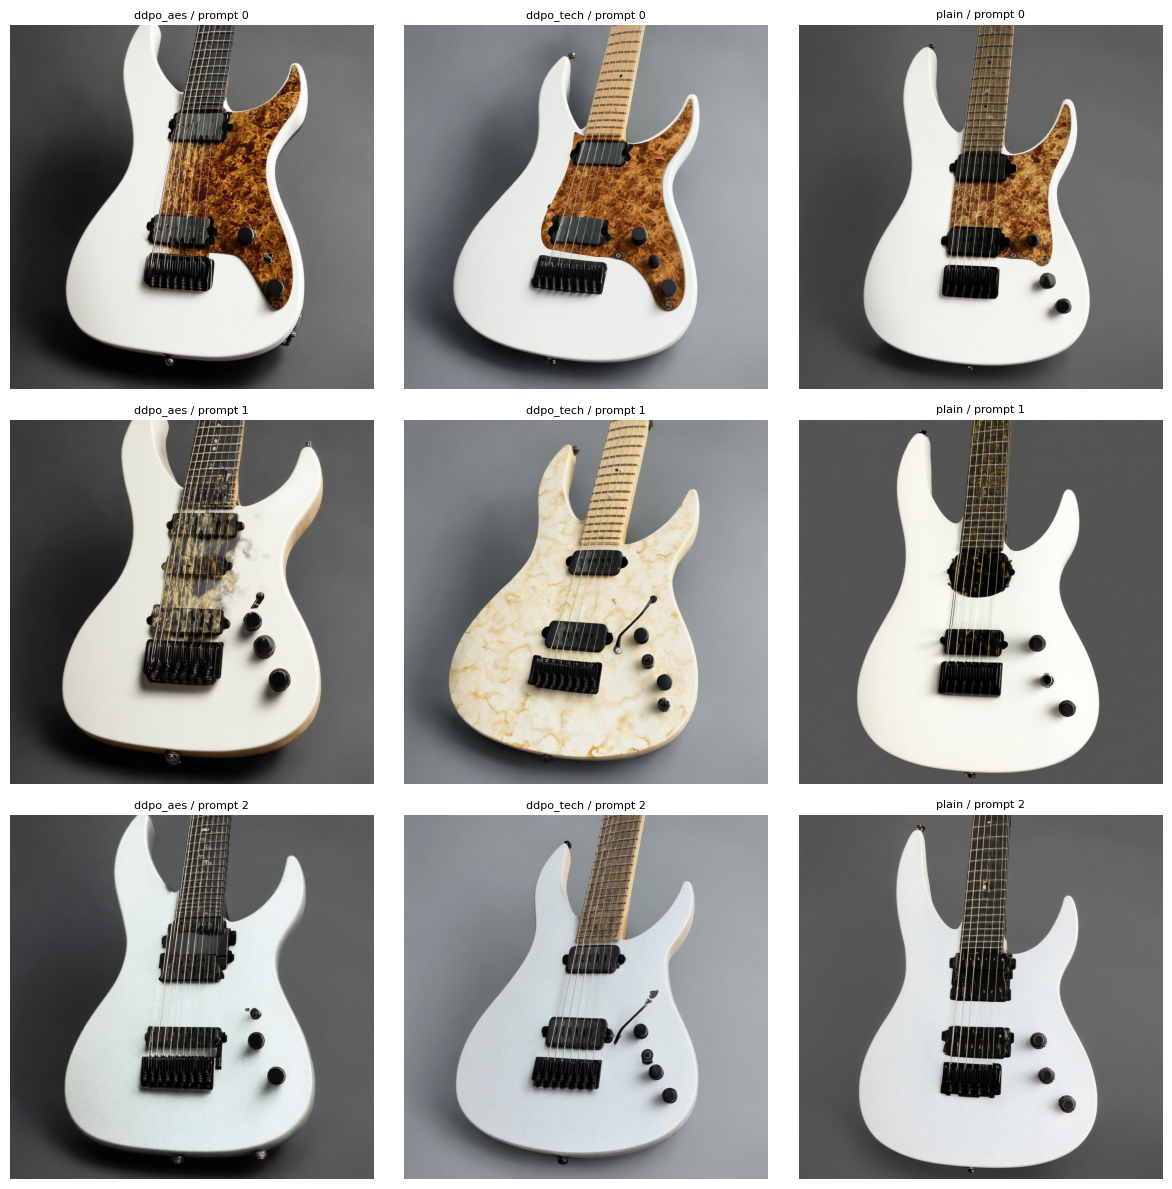

In [ ]:
import torch
from PIL import Image
import matplotlib.pyplot as plt
from train.dpo import load_policy_pipeline
from data.generate import prompts_from_manifest
prompts = prompts_from_manifest(MANIFEST)[:3]
imgs = {}
for tag, lora in [('plain', None), ('ddpo_aes', f'{RESULTS}/rl_aes/{RUN}'), ('ddpo_tech', f'{RESULTS}/rl_tech/lora_ddpo')]:
    if lora and not os.path.exists(f'{lora}/pytorch_lora_weights.safetensors'): continue
    pipe = load_policy_pipeline('stabilityai/stable-diffusion-3.5-medium', LORA, lora)
    for i, p in enumerate(prompts):
        g = torch.Generator('cpu').manual_seed(5)
        imgs[(tag, i)] = pipe(prompt=p, num_inference_steps=STEPS, guidance_scale=GUIDANCE, height=1024, width=1024, generator=g).images[0]
    del pipe; torch.cuda.empty_cache()
tags = sorted({t for t, _ in imgs})
fig, axs = plt.subplots(len(prompts), len(tags), figsize=(4 * len(tags), 4 * len(prompts)))
for i in range(len(prompts)):
    for j, t in enumerate(tags):
        axs[i, j].imshow(imgs[(t, i)]); axs[i, j].set_title(f'{t} / prompt {i}', fontsize=8); axs[i, j].axis('off')
plt.tight_layout(); plt.show()

## 6b. Checkpoint comparison — where does the drift start?

Same prompt + seed through the reference and every saved checkpoint of a run (`epoch_005`, `epoch_010`, …).
Pick the last epoch that still looks like the product; that folder goes to section 7 (`CKPT`).

Loading pipeline components...:   0%|          | 0/9 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

No LoRA keys associated to CLIPTextModelWithProjection found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModelWithProjection related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys associated to CLIPTextModelWithProjection found with the prefix='text_encoder_2'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModelWithProjection related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


...

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

No LoRA keys associated to CLIPTextModelWithProjection found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModelWithProjection related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys associated to CLIPTextModelWithProjection found with the prefix='text_encoder_2'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModelWithProjection related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

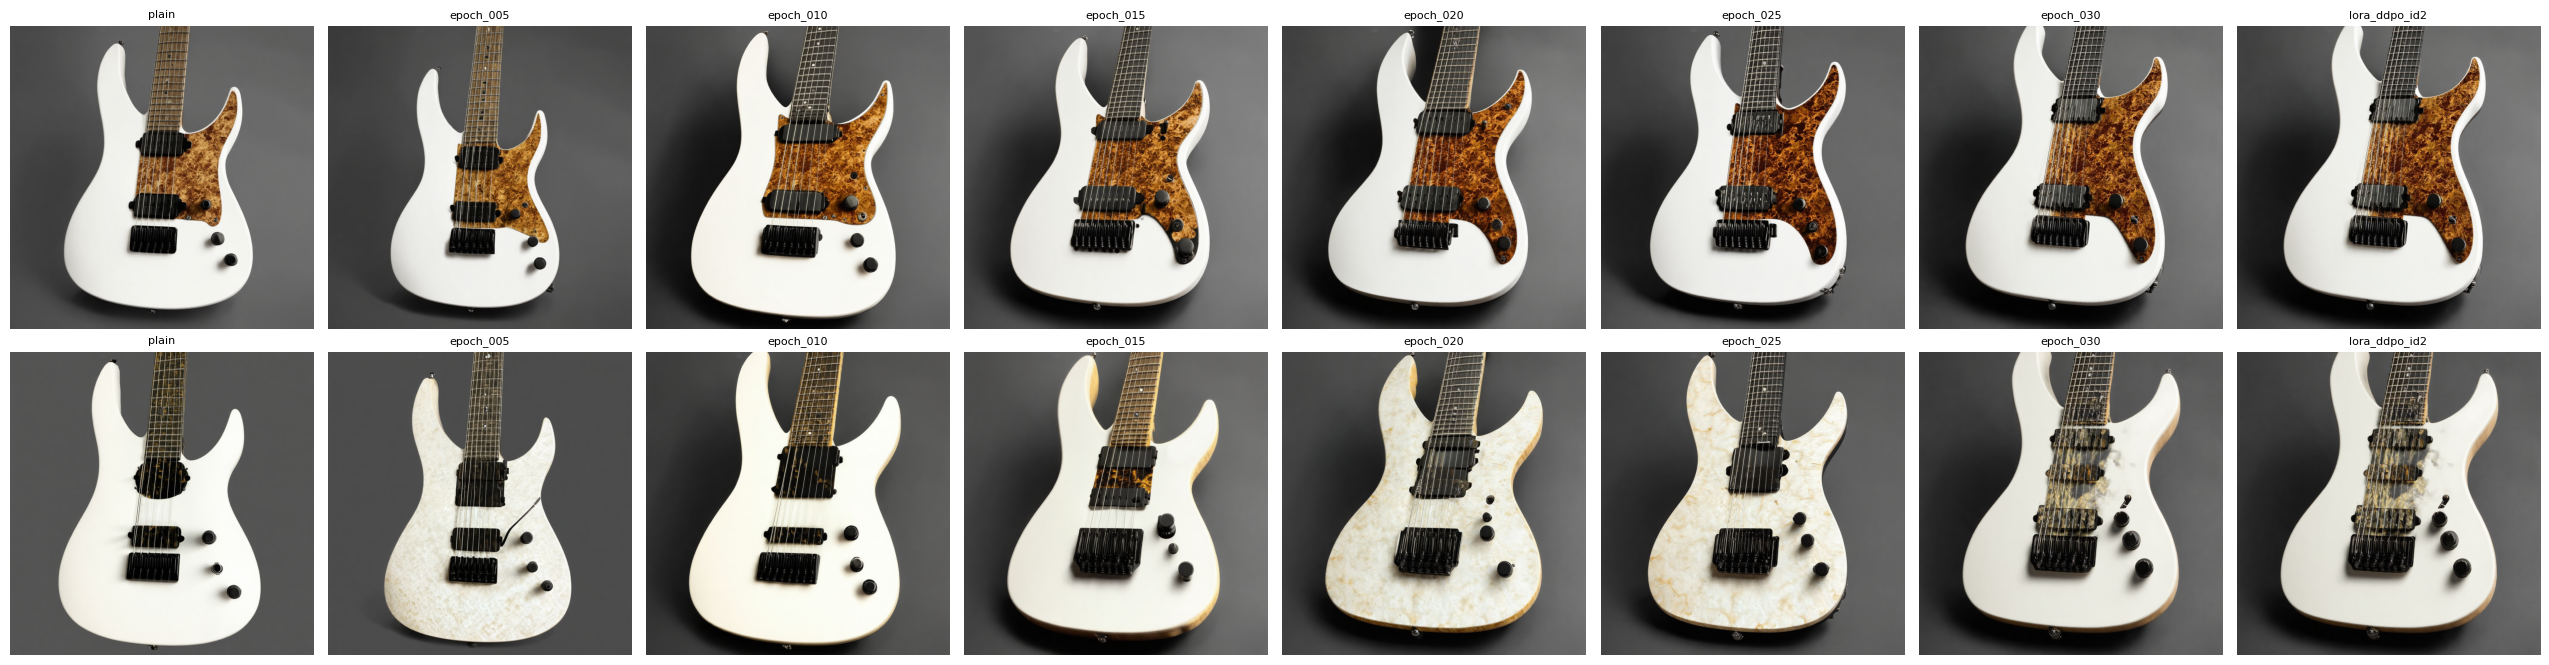

In [ ]:
import torch, glob
import matplotlib.pyplot as plt
from PIL import Image
from train.dpo import load_policy_pipeline
from data.generate import prompts_from_manifest

AXIS_DIR = 'rl_aes'                                   # rl_aes | rl_tech
SEED, N_PROMPTS = 5, 2
run_dir = f'{RESULTS}/{AXIS_DIR}/{RUN}'
ckpts = sorted(glob.glob(f'{run_dir}/epoch_*'))
if os.path.exists(f'{run_dir}/pytorch_lora_weights.safetensors'):
    ckpts.append(run_dir)
assert ckpts, f'no checkpoints in {run_dir}'
prompts = prompts_from_manifest(MANIFEST)[:N_PROMPTS]

# one pipeline (reference = rw LoRA fused), DPO/DDPO adapters swapped in and out
pipe = load_policy_pipeline('stabilityai/stable-diffusion-3.5-medium', LORA, None)
def gen(prompt):
    g = torch.Generator('cpu').manual_seed(SEED)
    return pipe(prompt=prompt, num_inference_steps=STEPS, guidance_scale=GUIDANCE, height=1024, width=1024, generator=g).images[0]

grid = {('plain', i): gen(p) for i, p in enumerate(prompts)}
for ck in ckpts:
    name = os.path.basename(ck)
    pipe.load_lora_weights(ck, adapter_name=name)
    pipe.set_adapters([name])
    for i, p in enumerate(prompts):
        grid[(name, i)] = gen(p)
    pipe.delete_adapters(name)
del pipe; torch.cuda.empty_cache()

cols = ['plain'] + [os.path.basename(c) for c in ckpts]
fig, axs = plt.subplots(len(prompts), len(cols), figsize=(3.2 * len(cols), 3.4 * len(prompts)), squeeze=False)
for i in range(len(prompts)):
    for j, name in enumerate(cols):
        axs[i, j].imshow(grid[(name, i)]); axs[i, j].axis('off'); axs[i, j].set_title(name, fontsize=8)
plt.tight_layout(); plt.show()

# pick the last checkpoint that still looks like the product, then point CKPT at it, e.g.
# CKPT = {'rl_aes': f'{run_dir}/epoch_010', 'rl_tech': f'{RESULTS}/rl_tech/{RUN}/epoch_010'}
CKPT = {'rl_aes': f'{RESULTS}/rl_aes/{RUN}', 'rl_tech': f'{RESULTS}/rl_tech/{RUN}'}

## 6c. Identity cost — CLIP similarity to the reference photos

`eval/identity.py` scores whole folders (first folder = baseline, pairwise deltas on matching paths).
Run it on the survey folders after section 7, or on the rollouts of two runs to compare `lora_ddpo`
(no identity term) with `{RUN}`.

In [ ]:
# survey folders (after section 7): identity of plain vs the two adapters, same prompt+seed
dirs = [f'{GEN2}/plain', f'{GEN2}/generated_rl_aes', f'{GEN2}/generated_rl_tech']
dirs = [d for d in dirs if os.path.exists(d)]
if len(dirs) > 1:
    !python eval/identity.py --refs {REFS[0]} {REFS[1]} --dirs {' '.join(dirs)} --limit 300 \
        --calib {RESULTS}/rl_aes/{RUN}/identity_calib.json --out {RESULTS}/identity_survey.csv
# rollouts: drift over epochs, no-identity run vs identity run
import pandas as pd
for run in ['lora_ddpo', RUN]:
    for d in ['rl_aes', 'rl_tech']:
        p = f'{RESULTS}/{d}/{run}/rollouts/rollouts.csv'
        if os.path.exists(p):
            ro = pd.read_csv(p)
            cols = [c for c in ['nima', 'laion_aes', 'musiq', 'topiq_nr', 'identity'] if c in ro.columns]
            print(f'{d}/{run}:'); display(ro.groupby('epoch')[cols].mean().round(3).iloc[::5])

NameError: name 'GEN2' is not defined

## 7. Survey images with the DDPO adapters

Same layout as `sd35_dpo_pool_extend.ipynb` section 9; `generated_v2/plain` must already exist.

In [ ]:
import os, shutil
GEN2     = f'{DATASET}/generated_v2'
GEN3 = f'{DATASET}/generated_v3'                       # survey set from the DDPO epoch-10 adapters
CKPT = {'rl_aes':  f'{RESULTS}/rl_aes/{RUN}/epoch_010',
        'rl_tech': f'{RESULTS}/rl_tech/lora_ddpo/epoch_030'}
for m, ck in CKPT.items():
    assert os.path.exists(f'{ck}/pytorch_lora_weights.safetensors'), f'missing checkpoint: {ck}'
print('adapters:', CKPT)

# plain: identical settings as generated_v2/plain -> copy instead of regenerating (2.5 h)
if os.path.exists(f'{GEN2}/plain/SD35') and not os.path.exists(f'{GEN3}/plain/SD35'):
    shutil.copytree(f'{GEN2}/plain', f'{GEN3}/plain')
    print('plain copied from generated_v2')
elif not os.path.exists(f'{GEN3}/plain/SD35'):
    !python eval/generate_triplets.py --method plain --catalog {CATALOG} --manifest {MANIFEST} \
        --plain-lora {LORA} --out {GEN3}/plain --no-suffix --steps {STEPS} --guidance {GUIDANCE}

# rl_aes / rl_tech: same prompt, seeds (available_seeds) and sampler; resumable
for m in ['rl_aes', 'rl_tech']:
    !python eval/generate_triplets.py --method {m} --catalog {CATALOG} --manifest {MANIFEST} \
        --plain-lora {LORA} --dpo-lora {CKPT[m]} --out {GEN3}/generated_{m} --no-suffix \
        --steps {STEPS} --guidance {GUIDANCE}

import glob
for m in ['plain', 'generated_rl_aes', 'generated_rl_tech']:
    print(f'{m:20s}', len(glob.glob(f'{GEN3}/{m}/**/*.png', recursive=True)), 'images')

adapters: {'rl_aes': '/content/drive/MyDrive/Doktorat/content/results/rl_aes/lora_ddpo_id2/epoch_010', 'rl_tech': '/content/drive/MyDrive/Doktorat/content/results/rl_tech/lora_ddpo/epoch_030'}
[triplets] prompts from manifest (178 color/top combos)
/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)
Loading pipeline components...:  11% 1/9 [00:00<00:01,  6.60it/s]
Loading weights:   0% 0/517 [00:00<?, ?it/s]
Loading weights:  32% 168/517 [00:00<00:00, 1529.68it/s]
Loading weights:  67% 344/517 [00:00<00:00, 1626.44it/s]
Loading weights: 100% 517/517 [00:00<00:00, 1631.27it/s]
Loading pipeline components...:  33% 3/9 [00:00<00:01,  3.86it/s]
Loading weights:   0% 0/219 [00:00<?, ?it/s]
Loading weights:   6% 13/219 [00:00<00:01, 124.37it/s]
Loading weights:  12% 26/219 [00:00<00:01, 

## 8. Upload the survey set to the company bucket

`auth.authenticate_user()` works ONLY with the account that runs this Colab (the private one) — picking another
account gives *credential propagation was unsuccessful*. So instead of switching accounts, the company project
grants the private account write access to its bucket (one command, run as the company account):

```
gcloud storage buckets add-iam-policy-binding gs://rufai-471714-images --member=user:<private-account>@gmail.com --role=roles/storage.objectAdmin
```
Details and bucket creation: `mos-eval/deploy/BUCKET-FIRMOWY.md`. Revoke the binding after the upload if you like.

In [30]:
BUCKET = 'rufai-471714-images'
GEN3 = f'{DATASET}/generated_v3'
from google.colab import auth; auth.authenticate_user()          # the PRIVATE account (the one running Colab)
!gcloud config set project rufai-471714
!gcloud storage rsync -r {GEN3} gs://{BUCKET}/rufgen/generated_v3   # resumable
!gcloud storage du -s gs://{BUCKET}/rufgen/generated_v3
!curl -sI https://storage.googleapis.com/{BUCKET}/rufgen/generated_v3/plain/SD35/arctic_white/burl/seed_0005.png | head -1

Are you sure you wish to set property [core/project] to rufai-471714?

Do you want to continue (Y/n)?  Y

Updated property [core/project].


To take a quick anonymous survey, run:
  $ gcloud survey

At gs://rufai-471714-images/rufgen/generated_v3/**, worker process 202970 thread 136005103288960 listed 2687...
At file:///content/drive/MyDrive/Doktorat/Dokumetacja/reward-GENERATED/Dataset/RufGen/generated_v3/**, worker process 202970 thread 136005103288960 listed 4050...
Copying file:///content/drive/MyDrive/Doktorat/Dokumetacja/reward-GENERATED/Dataset/RufGen/generated_v3/generated_rl_aes/SD35/arctic_white/binding_bound/seed_0000.png to gs://rufai-471714-images/rufgen/generated_v3/generated_rl_aes/SD35/arctic_white/binding_bound/seed_0000.png
Copying file:///content/drive/MyDrive/Doktorat/Dokumetacja/reward-GENERATED/Dataset/RufGen/generated_v3/generated_rl_aes/SD35/arctic_white/binding_bound/seed_0002.png to gs://rufai-471714-images/rufgen/generated_v3/generated_rl_aes/SD35/arctic_whit